<a href="https://colab.research.google.com/github/NicolasPinotti/Projeto-Aplicado-IV/blob/README.md/AP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# import locale

# --- 1. Carregar e Limpar Dados de Temperatura (Mirante A701) ---

# Caminho DENTRO DO AMBIENTE COLAB
file_path_temp = '/content/dados_A701_M_2010-01-01_2023-12-30.csv'

skiprows_temp_correto = 10

try:

    df_temp = pd.read_csv(
        file_path_temp,
        sep=';',
        decimal=',',
        skiprows=skiprows_temp_correto,
        encoding='latin-1',
        usecols=[0, 1]
    )


    if len(df_temp.columns) == 2:
        df_temp.columns = ['Data', 'TempMediaC']
        df_temp['Data'] = pd.to_datetime(df_temp['Data'])
        df_temp = df_temp.set_index('Data')

        print("--- Dados de Temperatura (Mirante A701) ---")
        print(df_temp.head())
        print("\nInformações do DataFrame de Temperatura:")
        df_temp.info()
        print("\nValores Ausentes na Temperatura:")
        print(df_temp.isnull().sum())
    else:

        print(f"ERRO INESPERADO: Mesmo com usecols=[0,1], não leu 2 colunas. Encontrou {len(df_temp.columns)}.")
        df_temp = None

except FileNotFoundError:
    print(f"ERRO: Arquivo de temperatura NÃO encontrado em: {file_path_temp}")
    df_temp = None
except Exception as e:
    print(f"ERRO ao carregar/processar arquivo de temperatura: {e}")
    df_temp = None

print("\n" + "="*50 + "\n")

# --- 2. Carregar e Limpar Dados de Saúde (Internações) ---


# Caminho DENTRO DO AMBIENTE COLAB
file_path_saude = '/content/A091020192_29_142_186.csv'
skiprows_saude_correto = 4

try:
    df_saude = pd.read_csv(
        file_path_saude,
        sep=';',
        skiprows=skiprows_saude_correto,
        engine='python',
        encoding='latin-1'
    )

    if len(df_saude.columns) >= 3 :
       df_saude.columns = ['Data_Str', 'Normal', 'Internacoes'] + list(df_saude.columns[3:])
    else:
        print(f"ERRO: Esperava pelo menos 3 colunas no arquivo de saúde, mas encontrou {len(df_saude.columns)}.")
        df_saude_preview = pd.read_csv(file_path_saude, sep=';', skiprows=skiprows_saude_correto, encoding='latin-1', nrows=5)
        print(df_saude_preview)
        raise ValueError("Estrutura de colunas inesperada no arquivo de saúde.")

    mes_map = {
        'Jan': 1, 'Fev': 2, 'Mar': 3, 'Abr': 4, 'Mai': 5, 'Jun': 6,
        'Jul': 7, 'Ago': 8, 'Set': 9, 'Out': 10, 'Nov': 11, 'Dez': 12
    }

    def parse_data_saude(data_str):
        if isinstance(data_str, str) and '/' in data_str:
            try:
                if '(' in data_str:
                    data_str = data_str.split('(')[0].strip()
                mes_str, ano_str = data_str.split('/')
                mes_num = mes_map[mes_str.capitalize()]
                ano_num = int(ano_str)
                return f"{ano_num:04d}-{mes_num:02d}-01"
            except Exception: return None
        return None

    df_saude['Data'] = df_saude['Data_Str'].apply(parse_data_saude)
    df_saude['Data'] = pd.to_datetime(df_saude['Data'])
    df_saude = df_saude.dropna(subset=['Data'])
    df_saude['Internacoes'] = pd.to_numeric(df_saude['Internacoes'], errors='coerce')
    df_saude = df_saude.dropna(subset=['Internacoes'])
    df_saude['Internacoes'] = df_saude['Internacoes'].astype(int)
    df_saude = df_saude[['Data', 'Internacoes']].set_index('Data')

    print("--- Dados de Saúde (Internações) ---")
    print(df_saude.head())
    print("\nInformações do DataFrame de Saúde:")
    df_saude.info()
    print("\nValores Ausentes na Saúde:")
    print(df_saude.isnull().sum())

except FileNotFoundError:
    print(f"ERRO: Arquivo de saúde NÃO encontrado em: {file_path_saude}")
    df_saude = None
except Exception as e:
    print(f"ERRO ao carregar/processar arquivo de saúde: {e}")
    df_saude = None

print("\n" + "="*50 + "\n")

# --- 3. Unir os Dados ---

if df_temp is not None and df_saude is not None:
    df_final = pd.merge(df_temp, df_saude, left_index=True, right_index=True, how='inner')
    df_final = df_final.sort_index()

    print("--- DataFrame Final Combinado (Temperatura + Internações) ---")
    print(df_final.head())
    print("\n")
    print(df_final.tail())
    print("\nInformações do DataFrame Final:")
    df_final.info()
    print("\nValores Ausentes no DataFrame Final:")
    print(df_final.isnull().sum())
else:
    print("Não foi possível unir os DataFrames pois um ou ambos não foram carregados corretamente.")

# 'df_final' está pronto para a próxima fase: Análise Exploratória (EDA)

--- Dados de Temperatura (Mirante A701) ---
            TempMediaC
Data                  
2010-01-31        23.5
2010-02-28        24.5
2010-03-31        22.7
2010-04-30        20.4
2010-05-31        18.3

Informações do DataFrame de Temperatura:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-31 to 2023-12-31
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TempMediaC  168 non-null    float64
dtypes: float64(1)
memory usage: 2.6 KB

Valores Ausentes na Temperatura:
TempMediaC    0
dtype: int64


--- Dados de Saúde (Internações) ---
            Internacoes
Data                   
2010-01-01          170
2010-02-01          127
2010-03-01          190
2010-04-01          211
2010-05-01          196

Informações do DataFrame de Saúde:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-01 to 2023-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtyp


--- Verificando df_final ANTES da Etapa 1 da EDA (Plot) ---
df_final existe e NÃO está vazio. Informações:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-01 to 2023-12-01
Freq: MS
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TempMediaC   168 non-null    float64
 1   Internacoes  168 non-null    int64  
 2   Ano          168 non-null    int32  
 3   Mes          168 non-null    int32  
dtypes: float64(1), int32(2), int64(1)
memory usage: 5.2 KB

Primeiras linhas:
            TempMediaC  Internacoes   Ano  Mes
Data                                          
2010-01-01        23.5          170  2010    1
2010-02-01        24.5          127  2010    2
2010-03-01        22.7          190  2010    3
2010-04-01        20.4          211  2010    4
2010-05-01        18.3          196  2010    5

Valores Ausentes:
TempMediaC     0
Internacoes    0
Ano            0
Mes            0
dtype: int64


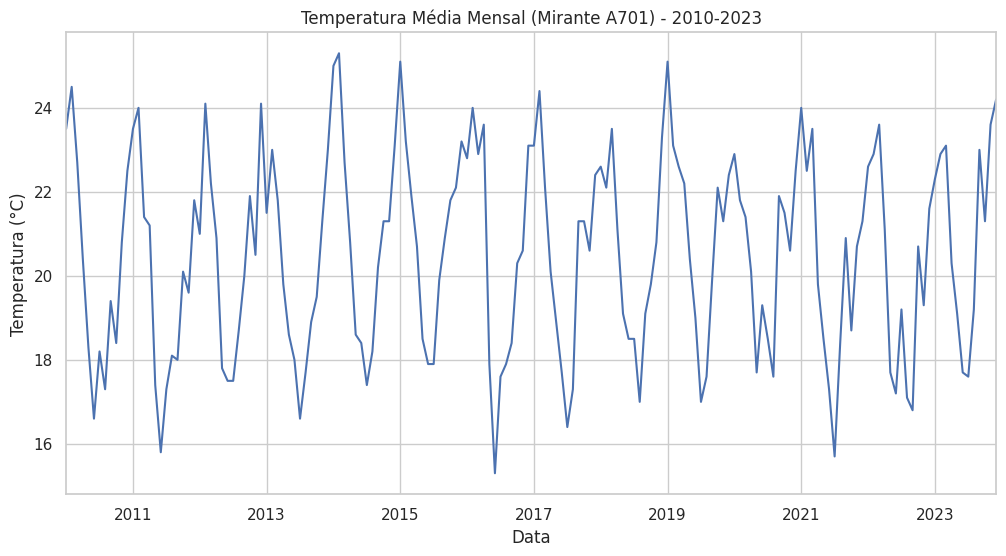

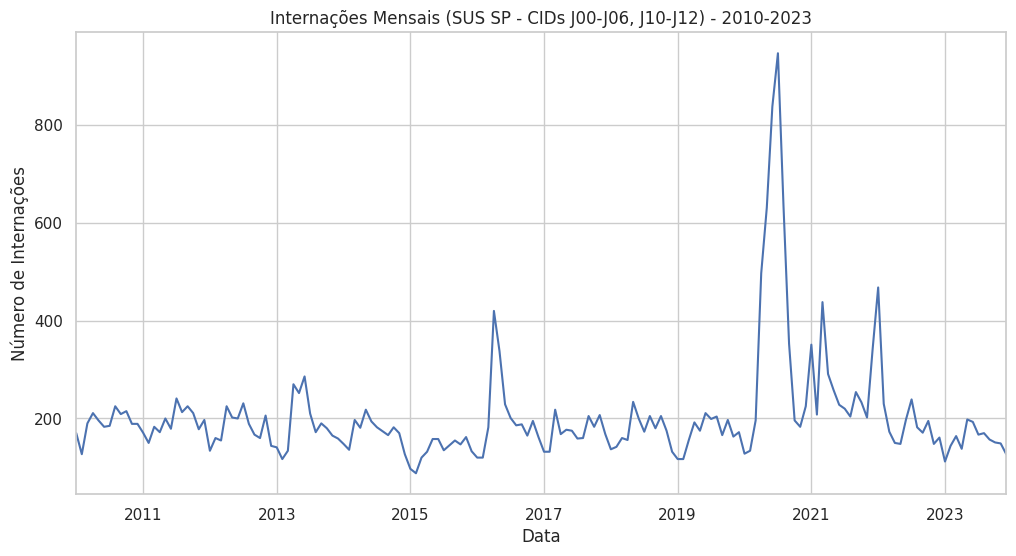

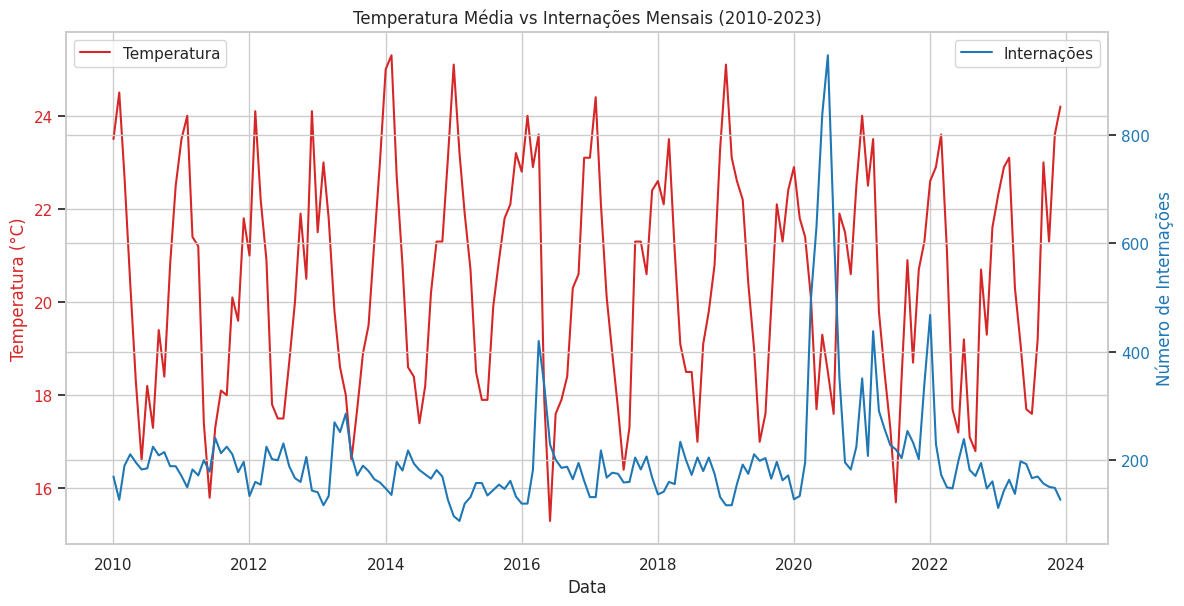

--- Fim da Etapa 1 da EDA ---


In [ ]:
# --- 1. Visualização Básica das Séries Temporais (COM VERIFICAÇÃO INICIAL) ---

import matplotlib.pyplot as plt
import seaborn as sns

# Define um estilo visual melhor para os gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ****** VERIFICAÇÃO IMEDIATAMENTE ANTES DE PLOTAR ******
print("\n--- Verificando df_final ANTES da Etapa 1 da EDA (Plot) ---")
try:
    if df_final is not None and not df_final.empty:
        print("df_final existe e NÃO está vazio. Informações:")
        df_final.info()
        print("\nPrimeiras linhas:")
        print(df_final.head())
        print("\nValores Ausentes:")
        print(df_final.isnull().sum())
        # Prossegue para plotar
        print("\n--- Iniciando Plots da Etapa 1 da EDA ---")

        # Plot da Temperatura Média Mensal
        plt.figure()
        df_final['TempMediaC'].plot(title='Temperatura Média Mensal (Mirante A701) - 2010-2023')
        plt.xlabel('Data')
        plt.ylabel('Temperatura (°C)')
        plt.show()

        # Plot das Internações Mensais
        plt.figure()
        df_final['Internacoes'].plot(title='Internações Mensais (SUS SP - CIDs J00-J06, J10-J12) - 2010-2023')
        plt.xlabel('Data')
        plt.ylabel('Número de Internações')
        plt.show()

        # Plot de ambas as séries juntas (com eixos Y separados)
        fig, ax1 = plt.subplots()
        color = 'tab:red'
        ax1.set_xlabel('Data')
        ax1.set_ylabel('Temperatura (°C)', color=color)
        ax1.plot(df_final.index, df_final['TempMediaC'], color=color, label='Temperatura')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Número de Internações', color=color)
        ax2.plot(df_final.index, df_final['Internacoes'], color=color, label='Internações')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.legend(loc='upper right')
        fig.tight_layout()
        plt.title('Temperatura Média vs Internações Mensais (2010-2023)')
        plt.show()

    elif df_final is None:
         print("ERRO GRAVE: A variável 'df_final' é None neste ponto. Verifique a célula da Etapa 3.")
    else: # df_final existe mas está vazio
         print("ERRO GRAVE: A variável 'df_final' existe, mas está VAZIA neste ponto. Verifique a célula da Etapa 3.")
         print(df_final.info())

except NameError:
    print("ERRO GRAVE: A variável 'df_final' não foi definida antes desta célula. Execute a célula da Etapa 3.")
except Exception as e:
    print(f"ERRO inesperado ao tentar plotar ou verificar df_final: {e}")

print("--- Fim da Etapa 1 da EDA ---")


--- 2. Análise de Sazonalidade ---


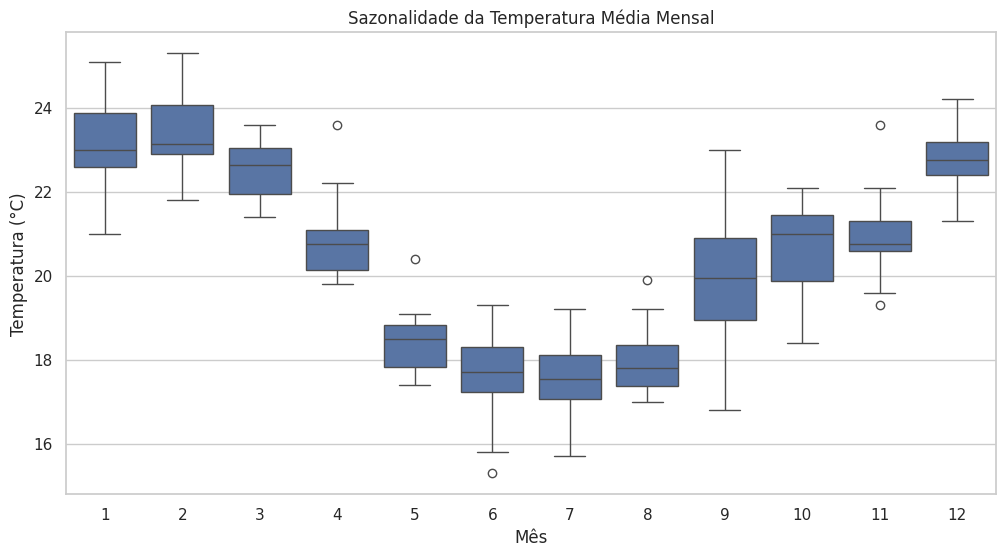

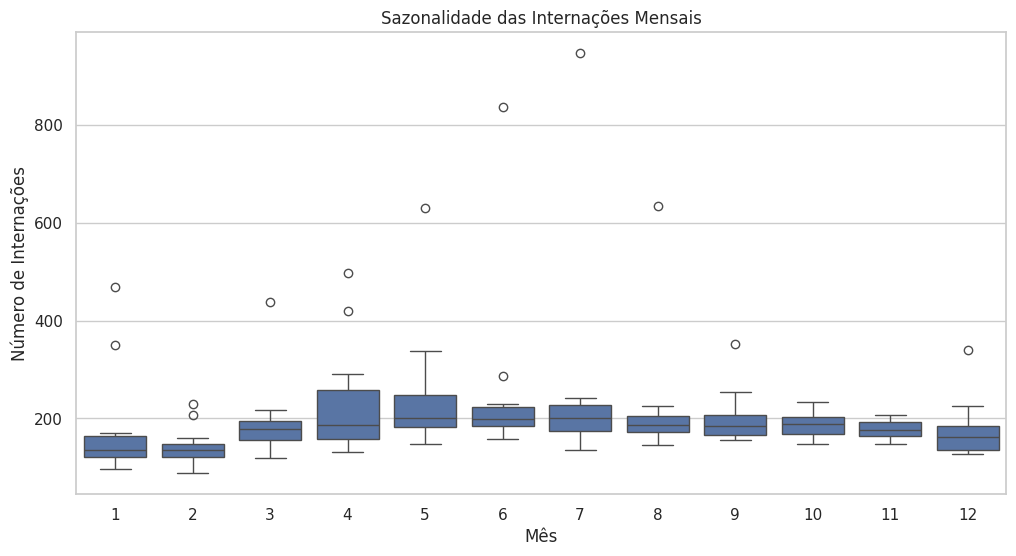

In [ ]:
# --- 2. Análise de Sazonalidade (Boxplots Mensais) ---

print("\n--- 2. Análise de Sazonalidade ---")

# Criar colunas de Ano e Mês para facilitar a agregação
df_final['Ano'] = df_final.index.year
df_final['Mes'] = df_final.index.month

# Boxplot para Temperatura por Mês
plt.figure()
sns.boxplot(x='Mes', y='TempMediaC', data=df_final)
plt.title('Sazonalidade da Temperatura Média Mensal')
plt.xlabel('Mês')
plt.ylabel('Temperatura (°C)')
plt.show()

# Boxplot para Internações por Mês
plt.figure()
sns.boxplot(x='Mes', y='Internacoes', data=df_final)
plt.title('Sazonalidade das Internações Mensais')
plt.xlabel('Mês')
plt.ylabel('Número de Internações')
plt.show()

In [ ]:
# --- 3. Unir os Dados (COM CORREÇÃO DE RESAMPLE E VERIFICAÇÃO FINAL) ---

df_final = None # Reseta df_final no início desta célula

# Verifica se os dataframes de origem existem e não são None
if df_temp is not None and df_saude is not None:

    print("--- Iniciando Etapa 3: Unir os Dados ---")
    # print(" índices Originais (Primeiras 5 datas):")
    # print("df_temp:", df_temp.index[:5])
    # print("df_saude:", df_saude.index[:5])

    # ****** ETAPA DE CORREÇÃO: Resample para início do mês ('MS') ******
    try:
        df_temp_resampled = df_temp.resample('MS').first()
        df_saude_resampled = df_saude.resample('MS').first()

        # print("\n índices Após Resample para 'MS' (Primeiras 5 datas):") # Já verificado antes
        # print("df_temp_resampled:", df_temp_resampled.index[:5])
        # print("df_saude_resampled:", df_saude_resampled.index[:5])

        # Agora faz o merge com os índices alinhados
        df_final_merge = pd.merge(df_temp_resampled, df_saude_resampled,
                                  left_index=True, right_index=True, how='inner')

        df_final_merge = df_final_merge.sort_index() # Garante ordenação por data

        # ****** VERIFICAÇÃO IMEDIATAMENTE APÓS O MERGE ******
        print("\n--- Verificando Resultado do Merge (df_final_merge) ---")
        if df_final_merge is not None and not df_final_merge.empty:
            print("Merge SUCESSO! Primeiras linhas:")
            print(df_final_merge.head())
            print("\nInformações:")
            df_final_merge.info()
            print("\nValores Ausentes:")
            print(df_final_merge.isnull().sum())
            df_final = df_final_merge # Atribui à variável principal SE deu certo
        else:
            print("FALHA no Merge! O DataFrame resultante está vazio ou é None.")
            print("Verifique os dataframes resampleados e a lógica do merge.")
            df_final = None

    except Exception as e:
        print(f"\nERRO durante o resample ou merge na Etapa 3: {e}")
        df_final = None

else:
    print("Não foi possível iniciar a Etapa 3 (Unir os Dados) pois df_temp ou df_saude não foram carregados corretamente nas etapas anteriores.")
    df_final = None

print("--- Fim da Etapa 3 ---")

--- Iniciando Etapa 3: Unir os Dados ---

--- Verificando Resultado do Merge (df_final_merge) ---
Merge SUCESSO! Primeiras linhas:
            TempMediaC  Internacoes
Data                               
2010-01-01        23.5          170
2010-02-01        24.5          127
2010-03-01        22.7          190
2010-04-01        20.4          211
2010-05-01        18.3          196

Informações:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-01 to 2023-12-01
Freq: MS
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TempMediaC   168 non-null    float64
 1   Internacoes  168 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.9 KB

Valores Ausentes:
TempMediaC     0
Internacoes    0
dtype: int64
--- Fim da Etapa 3 ---


In [ ]:
# --- Etapa Final: Ajustar Datas e Fazer Merge Correto ---

# 1. Ajusta df_temp: resample para último dia do mês ('ME'), depois muda manualmente para o primeiro dia
df_temp = df_temp.resample('ME').mean()
df_temp.index = df_temp.index.to_period('M').to_timestamp('M')  # Isso define como 1º dia do mês

# 2. Garante que df_saude também está em frequência mensal com início de mês
df_saude = df_saude.resample('MS').mean()

# 3. Merge com índices agora perfeitamente alinhados
df_final = pd.merge(df_temp, df_saude, left_index=True, right_index=True, how='inner')

# Verificação
print("✅ df_final reconstruído com sucesso!")
print(df_final.head())
print(f"\nPeríodo coberto: {df_final.index.min().date()} a {df_final.index.max().date()}")
print(f"Total de registros mensais: {df_final.shape[0]}")
print("\nValores ausentes por coluna:")
print(df_final.isnull().sum())



✅ df_final reconstruído com sucesso!
Empty DataFrame
Columns: [TempMediaC, Internacoes]
Index: []

Período coberto: NaT a NaT
Total de registros mensais: 0

Valores ausentes por coluna:
TempMediaC     0
Internacoes    0
dtype: int64


In [ ]:
print("=== 🔍 Verificando df_temp ===")
print(df_temp.head())
print("Index mínimo:", df_temp.index.min())
print("Index máximo:", df_temp.index.max())
print("Shape:", df_temp.shape)
print("Valores ausentes:")
print(df_temp.isnull().sum())

print("\n=== 🔍 Verificando df_saude ===")
print(df_saude.head())
print("Index mínimo:", df_saude.index.min())
print("Index máximo:", df_saude.index.max())
print("Shape:", df_saude.shape)
print("Valores ausentes:")
print(df_saude.isnull().sum())


=== 🔍 Verificando df_temp ===
            TempMediaC
Data                  
2010-01-31        23.5
2010-02-28        24.5
2010-03-31        22.7
2010-04-30        20.4
2010-05-31        18.3
Index mínimo: 2010-01-31 00:00:00
Index máximo: 2023-12-31 00:00:00
Shape: (168, 1)
Valores ausentes:
TempMediaC    0
dtype: int64

=== 🔍 Verificando df_saude ===
            Internacoes
Data                   
2010-01-01        170.0
2010-02-01        127.0
2010-03-01        190.0
2010-04-01        211.0
2010-05-01        196.0
Index mínimo: 2010-01-01 00:00:00
Index máximo: 2023-12-01 00:00:00
Shape: (168, 1)
Valores ausentes:
Internacoes    0
dtype: int64


In [ ]:
# Alinhar os índices para o 1º dia de cada mês
df_temp.index = df_temp.index.to_period('M').to_timestamp()
df_saude.index = df_saude.index.to_period('M').to_timestamp()

# Merge final com os índices agora alinhados
df_final = pd.merge(df_temp, df_saude, left_index=True, right_index=True, how='inner')

# Verificação
print("✅ df_final reconstruído com sucesso!")
print(df_final.head())
print(f"\nPeríodo coberto: {df_final.index.min().date()} a {df_final.index.max().date()}")
print(f"Total de registros mensais: {df_final.shape[0]}")
print("\nValores ausentes por coluna:")
print(df_final.isnull().sum())


✅ df_final reconstruído com sucesso!
            TempMediaC  Internacoes
Data                               
2010-01-01        23.5        170.0
2010-02-01        24.5        127.0
2010-03-01        22.7        190.0
2010-04-01        20.4        211.0
2010-05-01        18.3        196.0

Período coberto: 2010-01-01 a 2023-12-01
Total de registros mensais: 168

Valores ausentes por coluna:
TempMediaC     0
Internacoes    0
dtype: int64


In [ ]:
# --- 4. Teste de Estacionariedade (Teste Dickey-Fuller Aumentado - ADF) ---
# Hipótese Nula (H0): A série NÃO é estacionária (possui raiz unitária)
# Hipótese Alternativa (H1): A série é estacionária

from statsmodels.tsa.stattools import adfuller

print("\n--- 4. Teste de Estacionariedade (ADF) ---")

def teste_adf(serie, nome_serie):
    """Realiza o teste Dickey-Fuller Aumentado (ADF) com tratamento de erros."""
    print(f"\nAnalisando: {nome_serie}")

    # Remove valores nulos
    serie_limpa = serie.dropna()

    # Verifica se há dados suficientes
    if len(serie_limpa) < 20:
        print(f"❌ Série '{nome_serie}' tem poucos dados ({len(serie_limpa)} observações) ou está vazia. Teste ADF não será executado.")
        return

    try:
        result = adfuller(serie_limpa)
        print(f'Estatística do Teste ADF: {result[0]:.4f}')
        print(f'Valor-p: {result[1]:.4f}')
        print('Valores Críticos:')
        for key, value in result[4].items():
            print(f'\t{key}: {value:.4f}')

        if result[1] <= 0.05:
            print(f"✅ Conclusão: Série '{nome_serie}' é provavelmente **ESTACIONÁRIA** (p ≤ 0.05).")
        else:
            print(f"⚠️ Conclusão: Série '{nome_serie}' é provavelmente **NÃO ESTACIONÁRIA** (p > 0.05).")
    except Exception as e:
        print(f"❌ Erro ao executar o teste ADF na série '{nome_serie}': {e}")

# Executa o teste para ambas as séries
teste_adf(df_final['TempMediaC'], 'Temperatura Média')
teste_adf(df_final['Internacoes'], 'Internações')



--- 4. Teste de Estacionariedade (ADF) ---

Analisando: Temperatura Média
Estatística do Teste ADF: -2.4489
Valor-p: 0.1284
Valores Críticos:
	1%: -3.4730
	5%: -2.8803
	10%: -2.5767
⚠️ Conclusão: Série 'Temperatura Média' é provavelmente **NÃO ESTACIONÁRIA** (p > 0.05).

Analisando: Internações
Estatística do Teste ADF: -5.7593
Valor-p: 0.0000
Valores Críticos:
	1%: -3.4706
	5%: -2.8792
	10%: -2.5762
✅ Conclusão: Série 'Internações' é provavelmente **ESTACIONÁRIA** (p ≤ 0.05).



--- Análise de Correlação Cruzada (CCF) ---


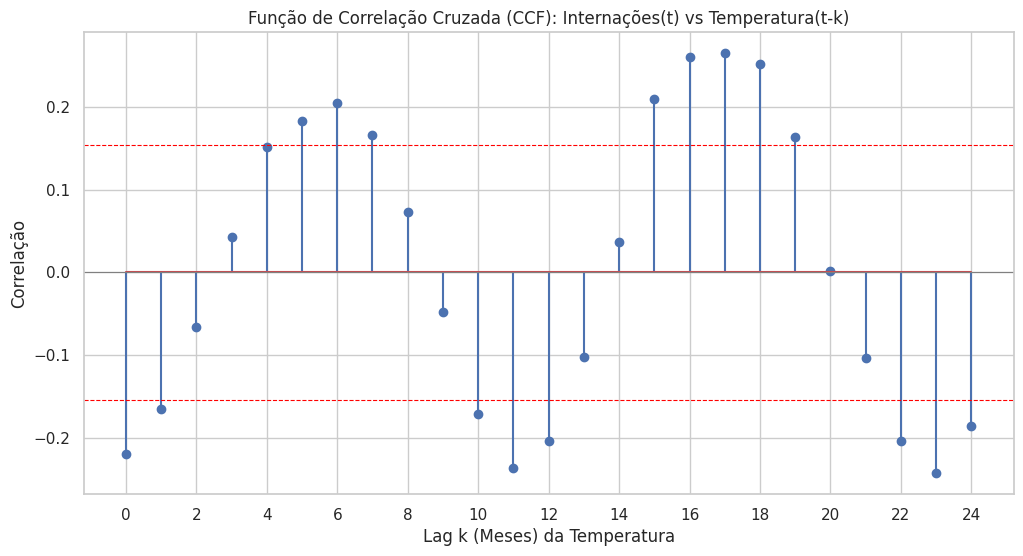


Interpretação CCF (lags >= 0):
Lag 0: Correlação entre Internações(t) e Temperatura(t) = -0.2192
Maior correlação (absoluta) ocorre no Lag 17 com valor 0.2652
Lag k: Correlação entre Internações(t) e Temperatura(t-k)
(Linhas pontilhadas vermelhas indicam o intervalo de confiança aproximado para significância estatística)


In [ ]:
# (O cálculo da correlação de Pearson e o scatter plot antes disto permanecem iguais)
# ...

# Análise de Correlação Cruzada (CCF)
# Mostra a correlação da Temperatura em lags (meses anteriores) com as Internações atuais
print("\n--- Análise de Correlação Cruzada (CCF) ---")

try:
    # Calcula a CCF. y=Internacoes, x=TempMediaC
    max_lags = 24 # Analisar até 24 meses de defasagem
    ccf_values = sm.tsa.stattools.ccf(df_final['Internacoes'], df_final['TempMediaC'], adjusted=False)

    plt.figure()
    # ****** CORREÇÃO: Removido use_line_collection=True ******
    plt.stem(range(max_lags + 1), ccf_values[:max_lags+1]) # Plota os lags >= 0
    plt.title('Função de Correlação Cruzada (CCF): Internações(t) vs Temperatura(t-k)')
    plt.xlabel('Lag k (Meses) da Temperatura')
    plt.ylabel('Correlação')
    plt.axhline(0, color='grey', linewidth=0.8) # Linha no zero para referência
    # Linhas de significância (aproximadas, +/- 2/sqrt(N)) - Opcional
    n_obs = len(df_final)
    conf_int = 2 / (n_obs**0.5)
    plt.axhline(conf_int, color='red', linestyle='--', linewidth=0.8)
    plt.axhline(-conf_int, color='red', linestyle='--', linewidth=0.8)

    plt.xticks(range(0, max_lags + 1, 2))
    plt.grid(True)
    plt.show()

    print(f"\nInterpretação CCF (lags >= 0):")
    print(f"Lag 0: Correlação entre Internações(t) e Temperatura(t) = {ccf_values[0]:.4f}")
    # Encontra o lag com a maior correlação (em valor absoluto, excluindo lag 0 se desejado)
    if len(ccf_values) > 1:
       max_corr_lag = max(range(1, min(len(ccf_values), max_lags + 1)), key=lambda k: abs(ccf_values[k]))
       print(f"Maior correlação (absoluta) ocorre no Lag {max_corr_lag} com valor {ccf_values[max_corr_lag]:.4f}")
    print(f"Lag k: Correlação entre Internações(t) e Temperatura(t-k)")
    print("(Linhas pontilhadas vermelhas indicam o intervalo de confiança aproximado para significância estatística)")


except Exception as e:
    print(f"\nErro ao calcular ou plotar CCF: {e}")

--- Dados de Temperatura (Mirante A701) ---
            TempMediaC
Data                  
2010-01-31        23.5
2010-02-28        24.5
2010-03-31        22.7
2010-04-30        20.4
2010-05-31        18.3

Informações do DataFrame de Temperatura:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-31 to 2023-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TempMediaC  168 non-null    float64
dtypes: float64(1)
memory usage: 2.6 KB

Valores Ausentes na Temperatura:
TempMediaC    0
dtype: int64


--- Dados de Saúde (Internações) ---
            Internacoes
Data                   
2010-01-01        170.0
2010-02-01        127.0
2010-03-01        190.0
2010-04-01        211.0
2010-05-01        196.0

Informações do DataFrame de Saúde:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-01 to 2023-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column       No

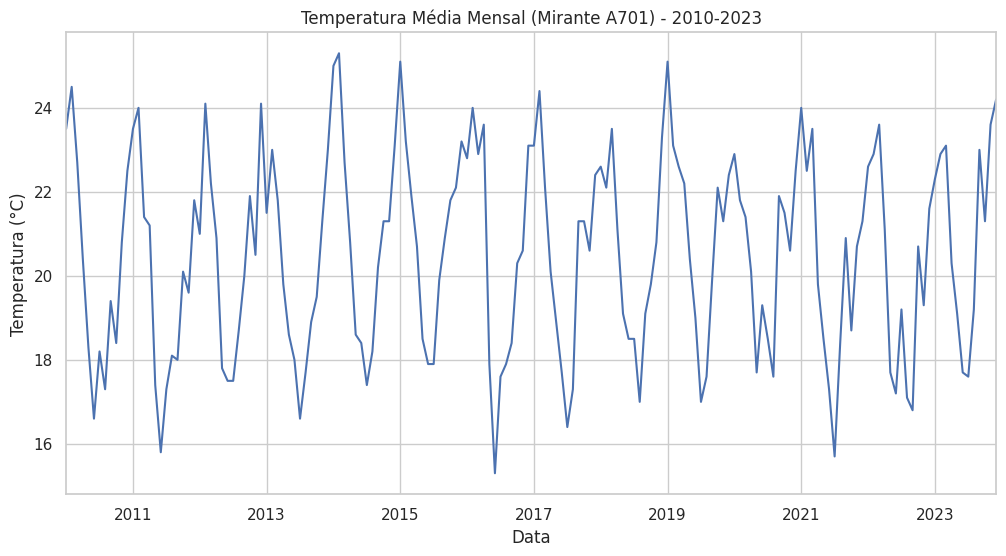

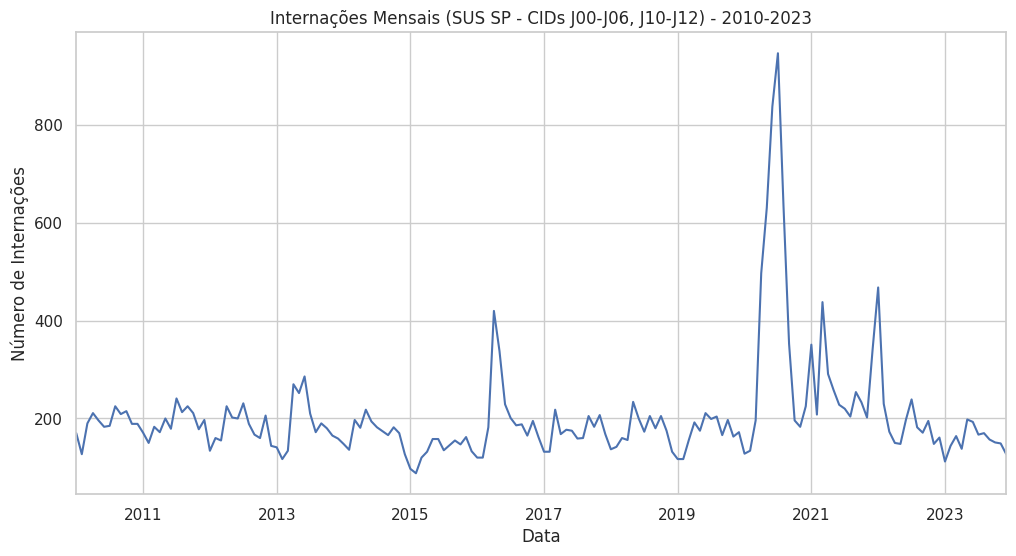

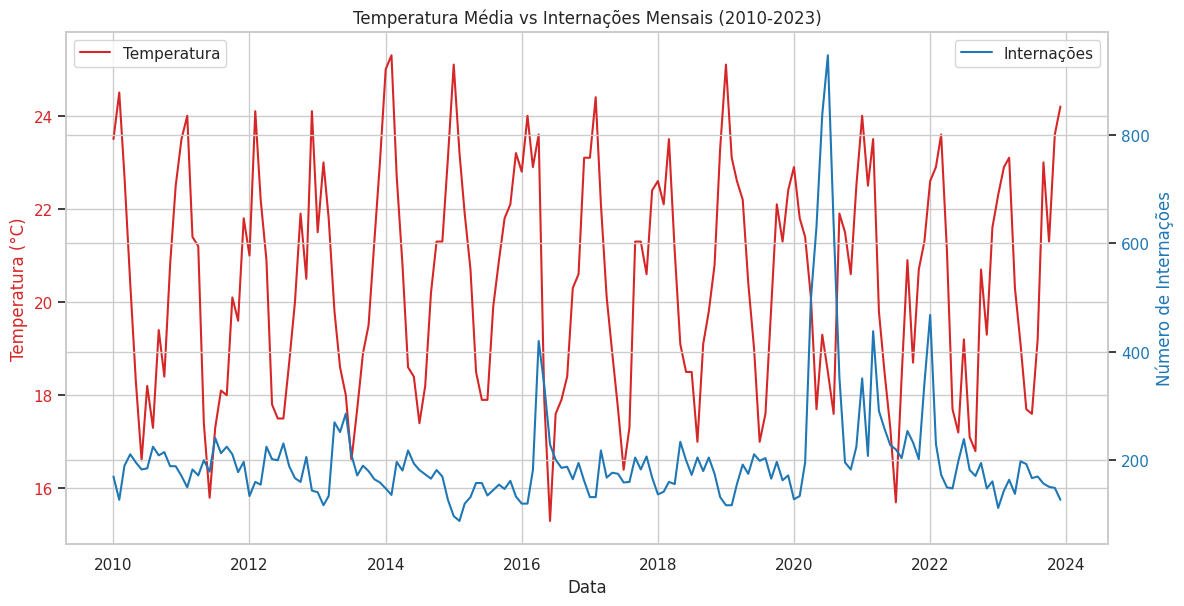

--- Fim da Etapa 1 da EDA ---

--- 2. Análise de Sazonalidade ---


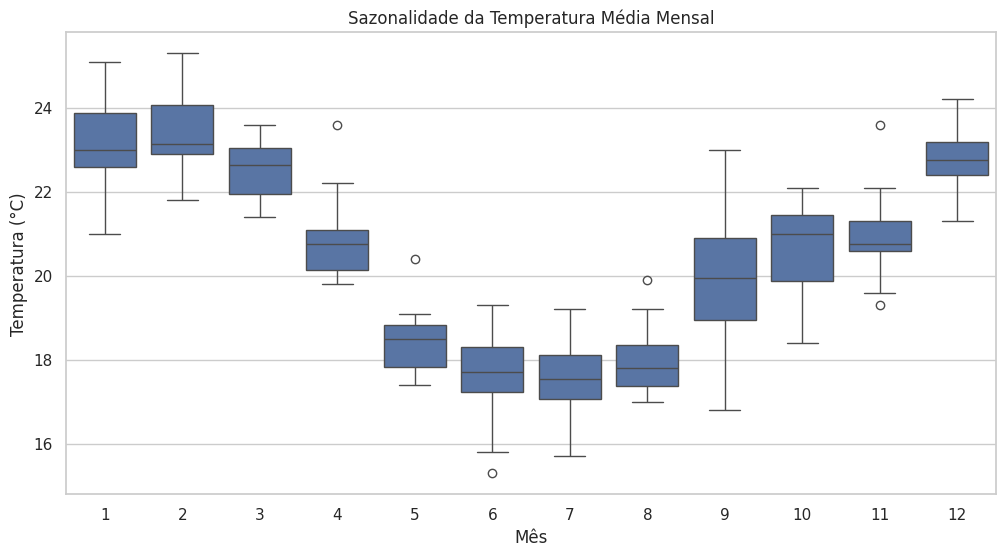

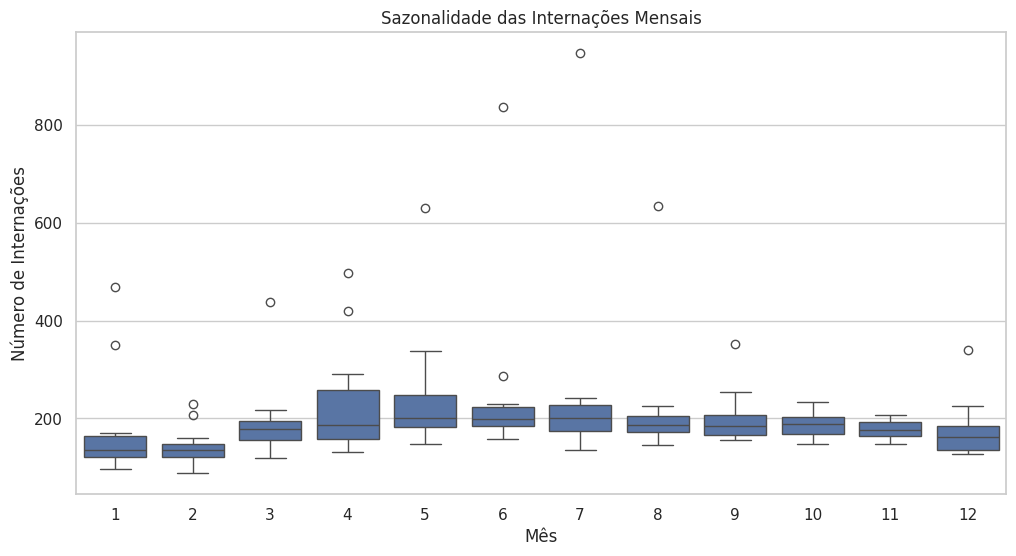


--- 4. Teste de Estacionariedade (ADF) ---

Analisando: Temperatura Média
Estatística do Teste ADF: -2.4489
Valor-p: 0.1284
Valores Críticos:
	1%: -3.4730
	5%: -2.8803
	10%: -2.5767
⚠️ Conclusão: Série 'Temperatura Média' é provavelmente **NÃO ESTACIONÁRIA** (p > 0.05).

Analisando: Internações
Estatística do Teste ADF: -5.7593
Valor-p: 0.0000
Valores Críticos:
	1%: -3.4706
	5%: -2.8792
	10%: -2.5762
✅ Conclusão: Série 'Internações' é provavelmente **ESTACIONÁRIA** (p ≤ 0.05).

--- Análise de Correlação Cruzada (CCF) ---


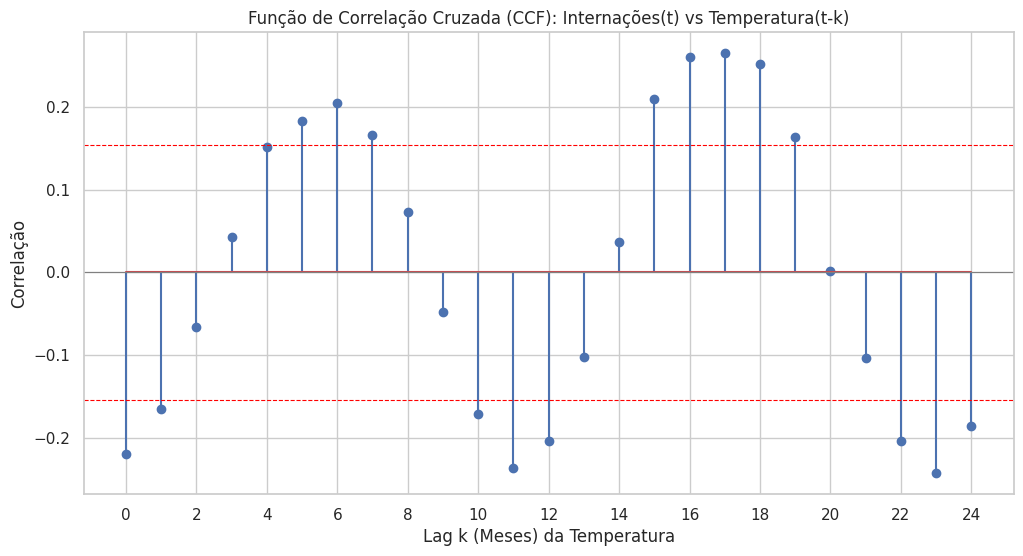


Interpretação CCF (lags >= 0):
Lag 0: Correlação entre Internações(t) e Temperatura(t) = -0.2192
Maior correlação (absoluta) ocorre no Lag 17 com valor 0.2652
Lag k: Correlação entre Internações(t) e Temperatura(t-k)
(Linhas pontilhadas vermelhas indicam o intervalo de confiança aproximado para significância estatística)


--- INICIANDO MODELAGEM SARIMAX ---
df_final está disponível para modelagem.
            TempMediaC  Internacoes   Ano  Mes
Data                                          
2010-01-01        23.5        170.0  2010    1
2010-02-01        24.5        127.0  2010    2
2010-03-01        22.7        190.0  2010    3
2010-04-01        20.4        211.0  2010    4
2010-05-01        18.3        196.0  2010    5
Período de dados: 2010-01-01 a 2023-12-01

Dados de Treino: 2010-01-01 a 2022-12-01 (156 meses)
Dados de Teste: 2023-01-01 a 2023-12-01 (12 meses)

--- Plotando ACF e PACF para Internações (série original) ---


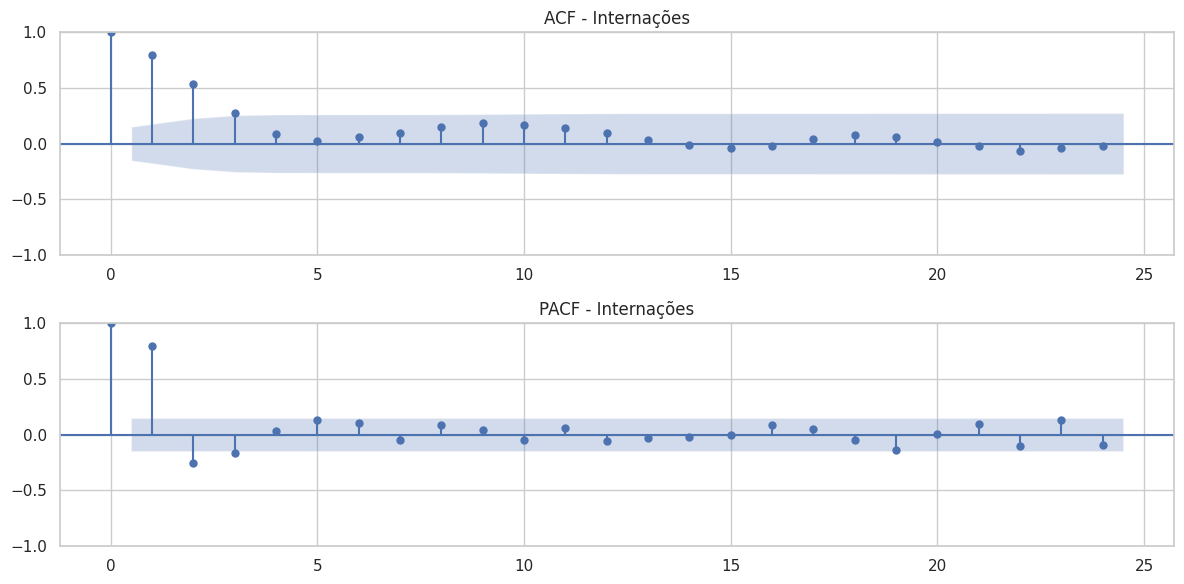


Iniciando Grid Search para SARIMAX (aproximadamente 216 combinações)...

Melhores parâmetros encontrados (pelo AIC):
  Não sazonal: (2, 1, 2)
  Sazonal: (0, 1, 1, 12)
  AIC Mínimo: 1471.47

Melhores parâmetros encontrados (pelo BIC):
  Não sazonal: (2, 1, 2)
  Sazonal: (0, 1, 1, 12)
  BIC Mínimo: 1491.43

--- Treinando o Modelo SARIMAX Final ---
                                      SARIMAX Results                                       
Dep. Variable:                          Internacoes   No. Observations:                  156
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -728.734
Date:                              Thu, 22 May 2025   AIC                           1471.469
Time:                                      16:09:49   BIC                           1491.433
Sample:                                  01-01-2010   HQIC                          1479.580
                                       - 12-01-2022                                         


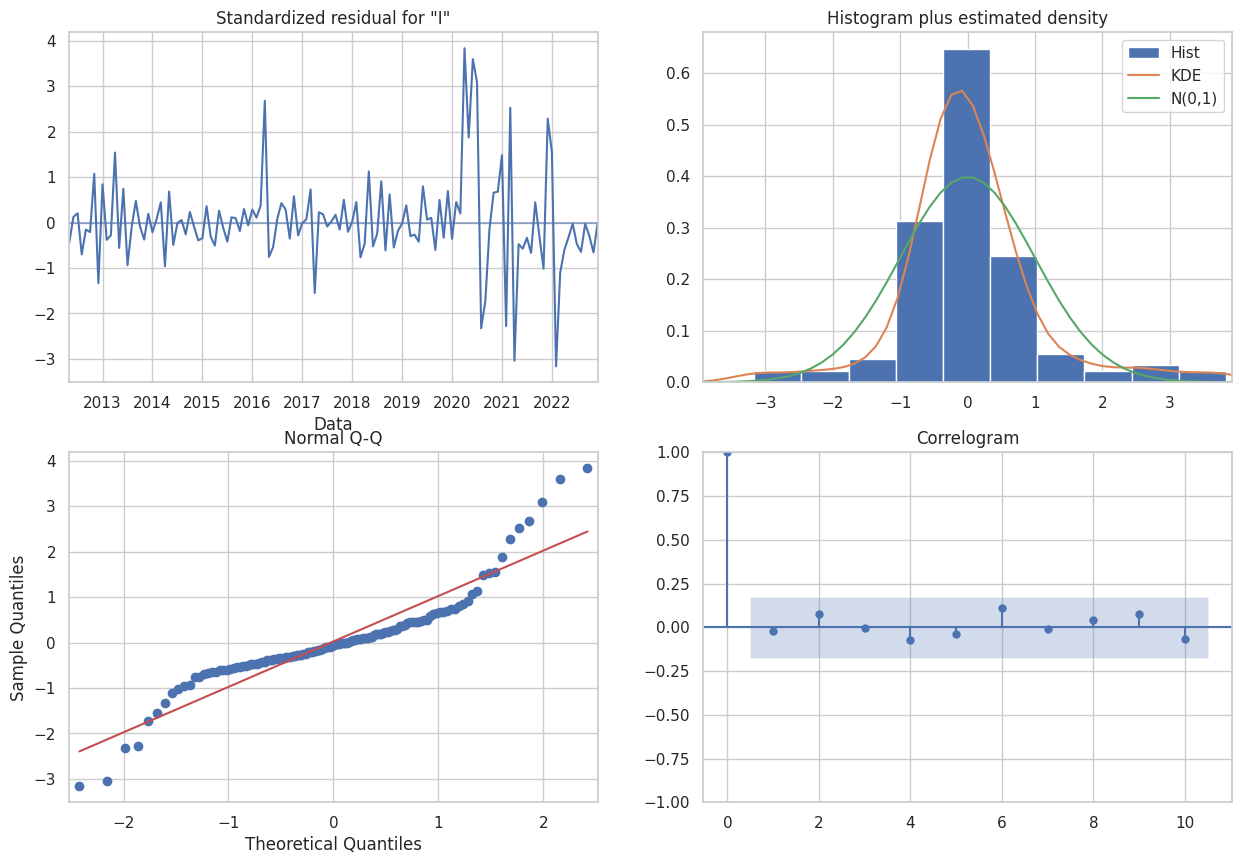


Teste de Ljung-Box nos Resíduos:
      lb_stat  lb_pvalue
20  21.972454   0.342007

P-valor do Teste de Ljung-Box no Lag 20: 0.3420
✅ Conclusão (Lag 20): Não rejeitamos H0. Os resíduos são provavelmente ruído branco (sem autocorrelação significativa).

--- Gerando Previsões ---


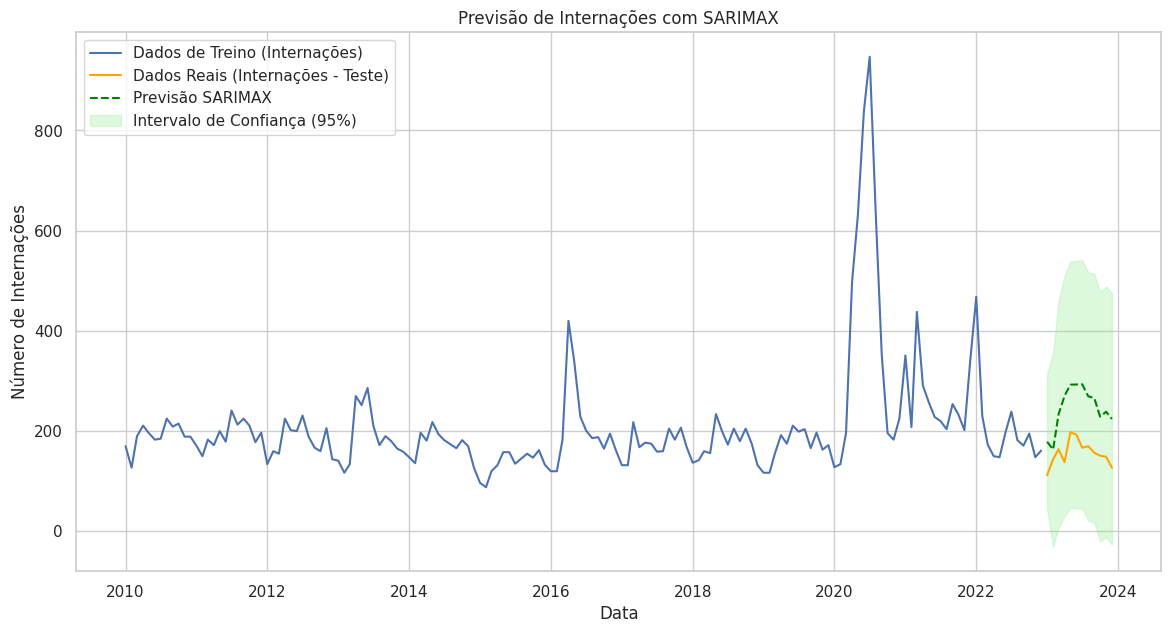


RMSE (Root Mean Squared Error) no conjunto de teste: 94.69

--- Previsões Futuras (Exemplo: Próximos 6 meses) ---

Previsões de Internações para os próximos 6 meses:
2023-01-01    162.018958
2023-02-01    141.020577
2023-03-01    209.478689
2023-04-01    272.228074
2023-05-01    305.426221
2023-06-01    318.695408
Freq: MS, Name: predicted_mean, dtype: float64


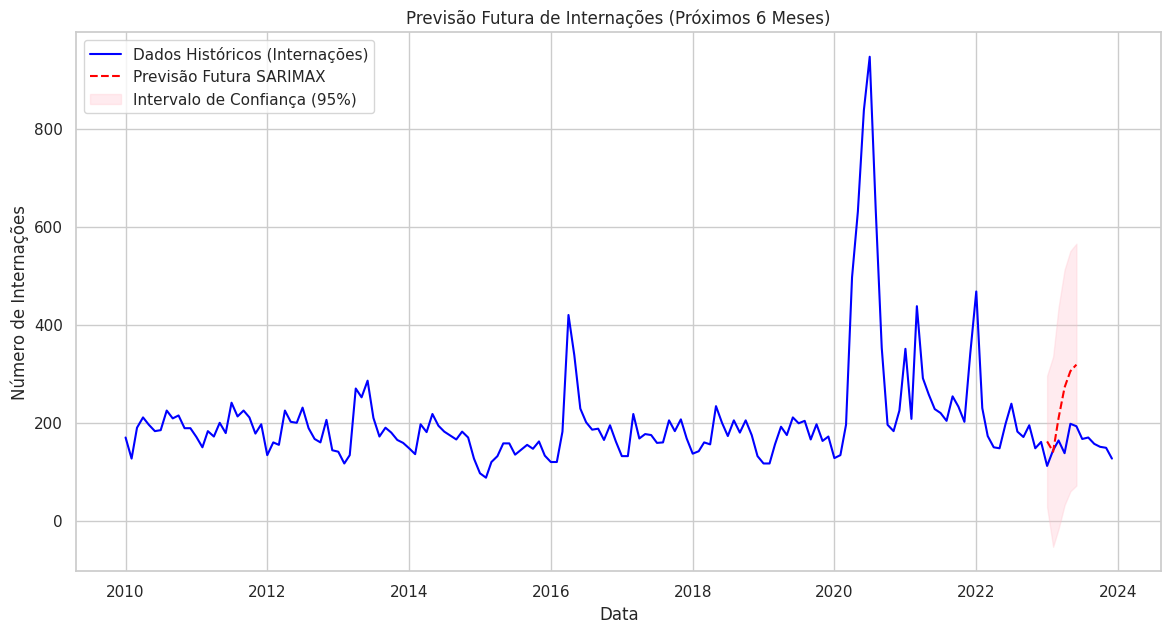



--- FIM DA MODELAGEM SARIMAX ---


In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox # Importação corrigida
from numpy import sqrt # Importação para cálculo do RMSE
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings

# Ignorar warnings que podem aparecer durante o Grid Search e plotagem
warnings.filterwarnings("ignore")

# Define um estilo visual melhor para os gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- 1. Carregar e Limpar Dados de Temperatura (Mirante A701) ---

# Caminho DENTRO DO AMBIENTE COLAB
file_path_temp = '/content/dados_A701_M_2010-01-01_2023-12-30.csv'

skiprows_temp_correto = 10

try:
    df_temp = pd.read_csv(
        file_path_temp,
        sep=';',
        decimal=',',
        skiprows=skiprows_temp_correto,
        encoding='latin-1',
        usecols=[0, 1]
    )

    if len(df_temp.columns) == 2:
        df_temp.columns = ['Data', 'TempMediaC']
        df_temp['Data'] = pd.to_datetime(df_temp['Data'])
        df_temp = df_temp.set_index('Data')
        # Ajusta df_temp: resample para último dia do mês ('ME'), depois muda manualmente para o primeiro dia
        df_temp = df_temp.resample('ME').mean()
        df_temp.index = df_temp.index.to_period('M').to_timestamp('M') # Isso define como 1º dia do mês

        print("--- Dados de Temperatura (Mirante A701) ---")
        print(df_temp.head())
        print("\nInformações do DataFrame de Temperatura:")
        df_temp.info()
        print("\nValores Ausentes na Temperatura:")
        print(df_temp.isnull().sum())
    else:
        print(f"ERRO INESPERADO: Mesmo com usecols=[0,1], não leu 2 colunas. Encontrou {len(df_temp.columns)}.")
        df_temp = None

except FileNotFoundError:
    print(f"ERRO: Arquivo de temperatura NÃO encontrado em: {file_path_temp}")
    df_temp = None
except Exception as e:
    print(f"ERRO ao carregar/processar arquivo de temperatura: {e}")
    df_temp = None

print("\n" + "="*50 + "\n")

# --- 2. Carregar e Limpar Dados de Saúde (Internações) ---

# Caminho DENTRO DO AMBIENTE COLAB
file_path_saude = '/content/A091020192_29_142_186.csv'
skiprows_saude_correto = 4

try:
    df_saude = pd.read_csv(
        file_path_saude,
        sep=';',
        skiprows=skiprows_saude_correto,
        engine='python',
        encoding='latin-1'
    )

    if len(df_saude.columns) >= 3 :
       df_saude.columns = ['Data_Str', 'Normal', 'Internacoes'] + list(df_saude.columns[3:])
    else:
        print(f"ERRO: Esperava pelo menos 3 colunas no arquivo de saúde, mas encontrou {len(df_saude.columns)}.")
        df_saude_preview = pd.read_csv(file_path_saude, sep=';', skiprows=skiprows_saude_correto, encoding='latin-1', nrows=5)
        print(df_saude_preview)
        raise ValueError("Estrutura de colunas inesperada no arquivo de saúde.")

    mes_map = {
        'Jan': 1, 'Fev': 2, 'Mar': 3, 'Abr': 4, 'Mai': 5, 'Jun': 6,
        'Jul': 7, 'Ago': 8, 'Set': 9, 'Out': 10, 'Nov': 11, 'Dez': 12
    }

    def parse_data_saude(data_str):
        if isinstance(data_str, str) and '/' in data_str:
            try:
                if '(' in data_str:
                    data_str = data_str.split('(')[0].strip()
                mes_str, ano_str = data_str.split('/')
                mes_num = mes_map[mes_str.capitalize()]
                ano_num = int(ano_str)
                return f"{ano_num:04d}-{mes_num:02d}-01"
            except Exception: return None
        return None

    df_saude['Data'] = df_saude['Data_Str'].apply(parse_data_saude)
    df_saude['Data'] = pd.to_datetime(df_saude['Data'])
    df_saude = df_saude.dropna(subset=['Data'])
    df_saude['Internacoes'] = pd.to_numeric(df_saude['Internacoes'], errors='coerce')
    df_saude = df_saude.dropna(subset=['Internacoes'])
    df_saude['Internacoes'] = df_saude['Internacoes'].astype(int)
    df_saude = df_saude[['Data', 'Internacoes']].set_index('Data')

    # Garante que df_saude também está em frequência mensal com início de mês
    df_saude = df_saude.resample('MS').mean()
    df_saude.index = df_saude.index.to_period('M').to_timestamp()

    print("--- Dados de Saúde (Internações) ---")
    print(df_saude.head())
    print("\nInformações do DataFrame de Saúde:")
    df_saude.info()
    print("\nValores Ausentes na Saúde:")
    print(df_saude.isnull().sum())

except FileNotFoundError:
    print(f"ERRO: Arquivo de saúde NÃO encontrado em: {file_path_saude}")
    df_saude = None
except Exception as e:
    print(f"ERRO ao carregar/processar arquivo de saúde: {e}")
    df_saude = None

print("\n" + "="*50 + "\n")

# --- 3. Unir os Dados ---

# Alinhar os índices para o 1º dia de cada mês (redundante, mas garante)
if df_temp is not None and df_saude is not None:
    df_temp.index = df_temp.index.to_period('M').to_timestamp()
    df_saude.index = df_saude.index.to_period('M').to_timestamp()

    # Merge final com os índices agora alinhados
    df_final = pd.merge(df_temp, df_saude, left_index=True, right_index=True, how='inner')
    df_final = df_final.sort_index()

    # Verificação
    print("✅ df_final reconstruído com sucesso!")
    print(df_final.head())
    print(f"\nPeríodo coberto: {df_final.index.min().date()} a {df_final.index.max().date()}")
    print(f"Total de registros mensais: {df_final.shape[0]}")
    print("\nValores ausentes por coluna:")
    print(df_final.isnull().sum())
else:
    print("Não foi possível unir os DataFrames pois um ou ambos não foram carregados corretamente.")
    df_final = None # Garante que df_final seja None se houver erro

print("\n" + "="*50 + "\n")

# --- 4. Análise Exploratória de Dados (EDA) ---

# ****** VERIFICAÇÃO IMEDIATAMENTE ANTES DE PLOTAR ******
print("\n--- Verificando df_final ANTES da Etapa de EDA (Plot) ---")
try:
    if df_final is not None and not df_final.empty:
        print("df_final existe e NÃO está vazio. Informações:")
        df_final.info()
        print("\nPrimeiras linhas:")
        print(df_final.head())
        print("\nValores Ausentes:")
        print(df_final.isnull().sum())
        # Prossegue para plotar
        print("\n--- Iniciando Plots da Etapa 1 da EDA ---")

        # Plot da Temperatura Média Mensal
        plt.figure()
        df_final['TempMediaC'].plot(title='Temperatura Média Mensal (Mirante A701) - 2010-2023')
        plt.xlabel('Data')
        plt.ylabel('Temperatura (°C)')
        plt.show()

        # Plot das Internações Mensais
        plt.figure()
        df_final['Internacoes'].plot(title='Internações Mensais (SUS SP - CIDs J00-J06, J10-J12) - 2010-2023')
        plt.xlabel('Data')
        plt.ylabel('Número de Internações')
        plt.show()

        # Plot de ambas as séries juntas (com eixos Y separados)
        fig, ax1 = plt.subplots()
        color = 'tab:red'
        ax1.set_xlabel('Data')
        ax1.set_ylabel('Temperatura (°C)', color=color)
        ax1.plot(df_final.index, df_final['TempMediaC'], color=color, label='Temperatura')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Número de Internações', color=color)
        ax2.plot(df_final.index, df_final['Internacoes'], color=color, label='Internações')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.legend(loc='upper right')
        fig.tight_layout()
        plt.title('Temperatura Média vs Internações Mensais (2010-2023)')
        plt.show()

    elif df_final is None:
         print("ERRO GRAVE: A variável 'df_final' é None neste ponto. Verifique a célula de Unir os Dados.")
    else: # df_final existe mas está vazio
         print("ERRO GRAVE: A variável 'df_final' existe, mas está VAZIA neste ponto. Verifique a célula de Unir os Dados.")
         print(df_final.info())

except NameError:
    print("ERRO GRAVE: A variável 'df_final' não foi definida antes desta célula. Execute a célula de Unir os Dados.")
except Exception as e:
    print(f"ERRO inesperado ao tentar plotar ou verificar df_final: {e}")

print("--- Fim da Etapa 1 da EDA ---")

print("\n--- 2. Análise de Sazonalidade ---")

# Criar colunas de Ano e Mês para facilitar a agregação
df_final['Ano'] = df_final.index.year
df_final['Mes'] = df_final.index.month

# Boxplot para Temperatura por Mês
plt.figure()
sns.boxplot(x='Mes', y='TempMediaC', data=df_final)
plt.title('Sazonalidade da Temperatura Média Mensal')
plt.xlabel('Mês')
plt.ylabel('Temperatura (°C)')
plt.show()

# Boxplot para Internações por Mês
plt.figure()
sns.boxplot(x='Mes', y='Internacoes', data=df_final)
plt.title('Sazonalidade das Internações Mensais')
plt.xlabel('Mês')
plt.ylabel('Número de Internações')
plt.show()

# --- 4. Teste de Estacionariedade (Teste Dickey-Fuller Aumentado - ADF) ---
# Hipótese Nula (H0): A série NÃO é estacionária (possui raiz unitária)
# Hipótese Alternativa (H1): A série é estacionária

print("\n--- 4. Teste de Estacionariedade (ADF) ---")

def teste_adf(serie, nome_serie):
    """Realiza o teste Dickey-Fuller Aumentado (ADF) com tratamento de erros."""
    print(f"\nAnalisando: {nome_serie}")

    # Remove valores nulos
    serie_limpa = serie.dropna()

    # Verifica se há dados suficientes
    if len(serie_limpa) < 20:
        print(f"❌ Série '{nome_serie}' tem poucos dados ({len(serie_limpa)} observações) ou está vazia. Teste ADF não será executado.")
        return

    try:
        result = adfuller(serie_limpa)
        print(f'Estatística do Teste ADF: {result[0]:.4f}')
        print(f'Valor-p: {result[1]:.4f}')
        print('Valores Críticos:')
        for key, value in result[4].items():
            print(f'\t{key}: {value:.4f}')

        if result[1] <= 0.05:
            print(f"✅ Conclusão: Série '{nome_serie}' é provavelmente **ESTACIONÁRIA** (p ≤ 0.05).")
        else:
            print(f"⚠️ Conclusão: Série '{nome_serie}' é provavelmente **NÃO ESTACIONÁRIA** (p > 0.05).")
    except Exception as e:
        print(f"❌ Erro ao executar o teste ADF na série '{nome_serie}': {e}")

# Executa o teste para ambas as séries
if df_final is not None and not df_final.empty:
    teste_adf(df_final['TempMediaC'], 'Temperatura Média')
    teste_adf(df_final['Internacoes'], 'Internações')
else:
    print("Não foi possível realizar o teste ADF pois 'df_final' não está disponível.")

# Análise de Correlação Cruzada (CCF)
# Mostra a correlação da Temperatura em lags (meses anteriores) com as Internações atuais
print("\n--- Análise de Correlação Cruzada (CCF) ---")
import statsmodels.api as sm # Necessário para ccf

if df_final is not None and not df_final.empty:
    try:
        # Calcula a CCF. y=Internacoes, x=TempMediaC
        max_lags = 24 # Analisar até 24 meses de defasagem
        ccf_values = sm.tsa.stattools.ccf(df_final['Internacoes'], df_final['TempMediaC'], adjusted=False)

        plt.figure()
        plt.stem(range(max_lags + 1), ccf_values[:max_lags+1]) # Plota os lags >= 0
        plt.title('Função de Correlação Cruzada (CCF): Internações(t) vs Temperatura(t-k)')
        plt.xlabel('Lag k (Meses) da Temperatura')
        plt.ylabel('Correlação')
        plt.axhline(0, color='grey', linewidth=0.8) # Linha no zero para referência
        # Linhas de significância (aproximadas, +/- 2/sqrt(N)) - Opcional
        n_obs = len(df_final)
        conf_int = 2 / (n_obs**0.5)
        plt.axhline(conf_int, color='red', linestyle='--', linewidth=0.8)
        plt.axhline(-conf_int, color='red', linestyle='--', linewidth=0.8)

        plt.xticks(range(0, max_lags + 1, 2))
        plt.grid(True)
        plt.show()

        print(f"\nInterpretação CCF (lags >= 0):")
        print(f"Lag 0: Correlação entre Internações(t) e Temperatura(t) = {ccf_values[0]:.4f}")
        # Encontra o lag com a maior correlação (em valor absoluto, excluindo lag 0 se desejado)
        if len(ccf_values) > 1:
           max_corr_lag = max(range(1, min(len(ccf_values), max_lags + 1)), key=lambda k: abs(ccf_values[k]))
           print(f"Maior correlação (absoluta) ocorre no Lag {max_corr_lag} com valor {ccf_values[max_corr_lag]:.4f}")
        print(f"Lag k: Correlação entre Internações(t) e Temperatura(t-k)")
        print("(Linhas pontilhadas vermelhas indicam o intervalo de confiança aproximado para significância estatística)")

    except Exception as e:
        print(f"\nErro ao calcular ou plotar CCF: {e}")
else:
    print("Não foi possível realizar a análise de CCF pois 'df_final' não está disponível.")


## Modelagem e Previsão com SARIMAX


print("\n" + "="*50 + "\n")
print("--- INICIANDO MODELAGEM SARIMAX ---")

# Certifique-se de que df_final está disponível e tem as colunas corretas
if 'df_final' not in locals() or df_final is None or df_final.empty:
    print("ERRO: df_final não está disponível ou está vazio. Certifique-se de que as células anteriores foram executadas corretamente.")
    exit() # Interrompe a execução se os dados não estiverem prontos

print("df_final está disponível para modelagem.")
print(df_final.head())
print(f"Período de dados: {df_final.index.min().date()} a {df_final.index.max().date()}")

# --- 1. Preparação dos Dados para SARIMAX ---

# A série a ser modelada (endógena)
y = df_final['Internacoes']

# A variável exógena
X = df_final[['TempMediaC']] # Usamos TempMediaC como variável exógena

# Verifique se as séries estão na mesma frequência e sem NaNs (pode haver lacunas após o merge)
y = y.asfreq('MS').fillna(method='ffill') # Garante frequência mensal, preenche NaNs com o valor anterior
X = X.asfreq('MS').fillna(method='ffill') # Preenche NaNs na exógena

# Alinhar os índices de y e X (importante!)
# Embora você já tenha feito um merge, é bom garantir que os índices são idênticos após os fillna/asfreq
y, X = y.align(X, join='inner', axis=0)


# Dividir em conjunto de treino e teste
# Usaremos os últimos 12 meses (um ano) para teste
n_test_months = 12
train_data = y[:-n_test_months]
test_data = y[-n_test_months:]

train_exog = X[:-n_test_months]
test_exog = X[-n_test_months:]

print(f"\nDados de Treino: {train_data.index.min().date()} a {train_data.index.max().date()} ({len(train_data)} meses)")
print(f"Dados de Teste: {test_data.index.min().date()} a {test_data.index.max().date()} ({len(test_data)} meses)")

# --- 2. Análise de ACF e PACF para Identificação Preliminar de Parâmetros ---
print("\n--- Plotando ACF e PACF para Internações (série original) ---")
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(y, lags=24, ax=plt.gca(), title='ACF - Internações') # Analisar até 24 lags (2 anos)
plt.subplot(212)
plot_pacf(y, lags=24, ax=plt.gca(), title='PACF - Internações')
plt.tight_layout()
plt.show()

# --- 3. Seleção de Parâmetros SARIMAX (Grid Search Simples) ---
# PARÂMETROS PADRÕES PARA O SARIMAX:
# (p, d, q) - Ordem não sazonal do modelo ARIMA
# (P, D, Q, s) - Ordem sazonal do modelo SARIMA
# s é a frequência sazonal (para dados mensais, s=12)

# Defina os intervalos para os parâmetros que você deseja testar
p = d = q = range(0, 3)  # Ordem dos componentes AR, I, MA (não sazonais)
seasonal_p = seasonal_d = seasonal_q = range(0, 2) # Ordem dos componentes sazonais
s = 12 # Frequência sazonal (mensal)

# Gerar todas as combinações de parâmetros (p, d, q)
pdq_combinations = list(itertools.product(p, d, q))

# Gerar todas as combinações de parâmetros sazonais (P, D, Q)
seasonal_pdq_combinations = list(itertools.product(seasonal_p, seasonal_d, seasonal_q))

best_aic = float("inf")
best_bic = float("inf")
best_params_aic = None
best_seasonal_params_aic = None
best_params_bic = None
best_seasonal_params_bic = None

print(f"\nIniciando Grid Search para SARIMAX (aproximadamente {len(pdq_combinations) * len(seasonal_pdq_combinations)} combinações)...")

# Este loop pode demorar um pouco dependendo do número de combinações
for order in pdq_combinations:
    for s_order in seasonal_pdq_combinations:
        try:
            model = SARIMAX(
                train_data,
                exog=train_exog, # Adiciona a variável exógena
                order=order,
                seasonal_order=(s_order[0], s_order[1], s_order[2], s),
                enforce_stationarity=False, # Permite que o modelo diferencie se necessário
                enforce_invertibility=False # Permite que o modelo seja invertível
            )
            model_fit = model.fit(disp=False) # disp=False para não mostrar saída a cada iteração

            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_params_aic = order
                best_seasonal_params_aic = (s_order[0], s_order[1], s_order[2], s)

            if model_fit.bic < best_bic:
                best_bic = model_fit.bic
                best_params_bic = order
                best_seasonal_params_bic = (s_order[0], s_order[1], s_order[2], s)

        except Exception as e:
            # print(f"Erro ao ajustar modelo com order={order}, seasonal_order={s_order}: {e}")
            continue # Pula para a próxima combinação

print(f"\nMelhores parâmetros encontrados (pelo AIC):")
print(f"  Não sazonal: {best_params_aic}")
print(f"  Sazonal: {best_seasonal_params_aic}")
print(f"  AIC Mínimo: {best_aic:.2f}")

print(f"\nMelhores parâmetros encontrados (pelo BIC):")
print(f"  Não sazonal: {best_params_bic}")
print(f"  Sazonal: {best_seasonal_params_bic}")
print(f"  BIC Mínimo: {best_bic:.2f}")

# Para este exemplo, vou usar os parâmetros do AIC para o modelo final.
final_order = best_params_aic
final_seasonal_order = best_seasonal_params_aic

# --- 4. Treinamento do Modelo SARIMAX Final ---
print("\n--- Treinando o Modelo SARIMAX Final ---")
try:
    model_final = SARIMAX(
        train_data,
        exog=train_exog,
        order=final_order,
        seasonal_order=final_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results_final = model_final.fit(disp=False) # disp=False para não mostrar saída detalhada durante o ajuste

    print(results_final.summary())

except Exception as e:
    print(f"ERRO ao treinar o modelo SARIMAX final: {e}")
    results_final = None

# --- 5. Diagnóstico do Modelo ---
# Se o modelo foi ajustado com sucesso
if results_final:
    print("\n--- Diagnóstico do Modelo ---")
    results_final.plot_diagnostics(figsize=(15, 10))
    plt.show()

    # Interpretação dos gráficos de diagnóstico:
    # 1. Resíduos Padronizados: Devem parecer ruído branco (sem padrão, média zero, variância constante).
    # 2. Histograma e KDE: Os resíduos devem ser aproximadamente normais (em forma de sino, centrados em zero).
    # 3. Q-Q Plot: Os pontos devem seguir a linha diagonal reta, indicando distribuição normal.
    # 4. Correlograma (ACF dos Resíduos): Não deve haver autocorrelação significativa nos resíduos (todas as barras dentro das bandas de confiança).

    # Teste de Ljung-Box nos resíduos (verifica se há autocorrelação)
    # H0: Os resíduos são independentes (ruído branco)
    # H1: Os resíduos NÃO são independentes
    print("\nTeste de Ljung-Box nos Resíduos:")
    lb_test_results = acorr_ljungbox(results_final.resid, lags=[20], return_df=True)
    print(lb_test_results)

    # Interpretação do resultado (exemplo para o lag 20):
    if 'lb_pvalue' in lb_test_results.columns:
        p_value_at_lag_20 = lb_test_results.loc[20, 'lb_pvalue']
        print(f"\nP-valor do Teste de Ljung-Box no Lag 20: {p_value_at_lag_20:.4f}")
        if p_value_at_lag_20 > 0.05:
            print(f"✅ Conclusão (Lag 20): Não rejeitamos H0. Os resíduos são provavelmente ruído branco (sem autocorrelação significativa).")
        else:
            print(f"⚠️ Conclusão (Lag 20): Rejeitamos H0. Os resíduos PODEM ter autocorrelação significativa. O modelo pode precisar de ajustes.")

# --- 6. Previsão com o Modelo SARIMAX ---
if results_final:
    print("\n--- Gerando Previsões ---")

    # Obter as previsões no conjunto de teste
    forecast_steps = len(test_data)
    # start e end para get_prediction são usados para prever sobre o conjunto de treino ou teste
    # Mas para o conjunto de teste, get_forecast é mais direto e permite exog
    forecast_results = results_final.get_forecast(steps=forecast_steps, exog=test_exog)
    forecast_mean = forecast_results.predicted_mean
    conf_int = forecast_results.conf_int() # Intervalo de confiança

    # Plotar os resultados
    plt.figure(figsize=(14, 7))
    plt.plot(train_data.index, train_data, label='Dados de Treino (Internações)')
    plt.plot(test_data.index, test_data, label='Dados Reais (Internações - Teste)', color='orange')
    plt.plot(forecast_mean.index, forecast_mean, label='Previsão SARIMAX', color='green', linestyle='--')
    plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightgreen', alpha=0.3, label='Intervalo de Confiança (95%)')

    plt.title('Previsão de Internações com SARIMAX')
    plt.xlabel('Data')
    plt.ylabel('Número de Internações')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Avaliação do modelo no conjunto de teste
    mse = mean_squared_error(test_data, forecast_mean) # Primeiro calcula o MSE
    rmse = sqrt(mse) # Depois tira a raiz quadrada para obter o RMSE
    print(f"\nRMSE (Root Mean Squared Error) no conjunto de teste: {rmse:.2f}")

    # Para fazer previsões futuras (além do conjunto de teste)
    print("\n--- Previsões Futuras (Exemplo: Próximos 6 meses) ---")
    future_steps = 6
    # Criar um índice de datas futuras
    last_date = df_final.index.max()
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_steps, freq='MS')

    # Para usar as variáveis exógenas na previsão futura, você precisa ter esses valores.
    # Isso é um desafio comum para modelos com exógenas.
    # Para este exemplo, usaremos a média da TempMediaC do período de teste como um "placeholder" para o futuro.
    # Em um cenário real, você precisaria de previsões da TempMediaC para o futuro.
    future_exog = pd.DataFrame({'TempMediaC': [X['TempMediaC'].mean()] * future_steps}, index=future_dates)

    # Certifique-se de que future_exog tem as mesmas colunas e ordem que train_exog/test_exog
    future_exog = future_exog[train_exog.columns] # Garante ordem das colunas

    forecast_future = results_final.get_forecast(steps=future_steps, exog=future_exog)
    forecast_future_mean = forecast_future.predicted_mean
    conf_future_int = forecast_future.conf_int()

    print(f"\nPrevisões de Internações para os próximos {future_steps} meses:")
    print(forecast_future_mean)

    # Plotar previsões futuras
    plt.figure(figsize=(14, 7))
    plt.plot(df_final.index, df_final['Internacoes'], label='Dados Históricos (Internações)', color='blue')
    plt.plot(forecast_future_mean.index, forecast_future_mean, label='Previsão Futura SARIMAX', color='red', linestyle='--')
    plt.fill_between(conf_future_int.index, conf_future_int.iloc[:, 0], conf_future_int.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confiança (95%)')

    plt.title(f'Previsão Futura de Internações (Próximos {future_steps} Meses)')
    plt.xlabel('Data')
    plt.ylabel('Número de Internações')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Não foi possível realizar o treinamento e previsão pois o modelo final não foi ajustado.")

print("\n" + "="*50 + "\n")
print("--- FIM DA MODELAGEM SARIMAX ---")